<a href="https://colab.research.google.com/github/shriyareddy27/ml-20/blob/main/day01_first_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — Your First ML Pipeline

**Goal today:** run a complete machine learning pipeline, break it on purpose, then rebuild it from scratch on a dataset you haven't seen.

Time: about 3 hours. The last section is the one that actually teaches you something — don't skip it because you're tired.

**Rule for today: type the code, don't copy-paste it.** It feels slower. It isn't.

---
## Part 1 — The pipeline that works (20 min)

Every supervised ML task, no matter how complex, is these five steps. Run this cell and you've done machine learning.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Get data:  X = features (measurements), y = labels (the answer)
X, y = load_iris(return_X_y=True)

# 2. Split: the model never sees the test set during training
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)

# 4. Predict on data the model has never seen
pred = model.predict(X_te)

# 5. Evaluate
print("Accuracy:", accuracy_score(y_te, pred))
print(confusion_matrix(y_te, pred))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Understand what you just saw

Before moving on, run these and make sure the shapes make sense to you.

In [2]:
print("X shape:", X.shape)     # (rows = samples, columns = features)
print("y shape:", y.shape)     # one label per sample
print("Train samples:", X_tr.shape[0], "| Test samples:", X_te.shape[0])
print("First 3 samples:\n", X[:3])
print("First 10 labels:", y[:10])

X shape: (150, 4)
y shape: (150,)
Train samples: 120 | Test samples: 30
First 3 samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
First 10 labels: [0 0 0 0 0 0 0 0 0 0]


**Reading the confusion matrix.** Rows are the true class, columns are what the model predicted. The diagonal is correct predictions; everything off the diagonal is a mistake, and *where* the mistake sits tells you which classes the model confuses. That's information accuracy alone hides — a model can be 95% accurate and still fail completely on the one class you actually care about.

> **Write in your notes:** for the matrix you just printed, which class (if any) did the model get wrong?

---
## Part 2 — Break it on purpose (30 min)

`test_size` decides how much data the model trains on. Change it and watch what happens.

In [4]:
for ts in [0.2, 0.5, 0.9]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=ts, random_state=42)
    m = RandomForestClassifier(random_state=0).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    print(f"test_size={ts}  ->  trained on {X_tr.shape[0]:3d} samples  ->  accuracy {acc:.3f}")

test_size=0.2  ->  trained on 120 samples  ->  accuracy 1.000
test_size=0.5  ->  trained on  75 samples  ->  accuracy 0.987
test_size=0.9  ->  trained on  15 samples  ->  accuracy 0.956


> **Think:** less training data means worse performance — but notice how *slowly* accuracy falls here. Iris is an easy dataset. Real ones punish small training sets much harder.

Now try changing `random_state=42` to `random_state=0` and rerun. Does accuracy move? That instability is exactly why a single train/test split can't be trusted, and why cross-validation exists (you'll meet it on day 5).

---
## Part 3 — Swap the model (30 min)

The scikit-learn API is deliberately identical across every model: `.fit()` then `.predict()`. Learn it once, use it everywhere.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
}

for name, m in models.items():
    m.fit(X_tr, y_tr)
    print(f"{name:20s} {accuracy_score(y_te, m.predict(X_te)):.3f}")

LogisticRegression   1.000
DecisionTree         1.000
RandomForest         1.000


### Which features mattered?

Tree-based models can tell you which inputs drove their decisions. This is your first taste of interpretability — a big deal in any field where you have to justify a prediction to someone.

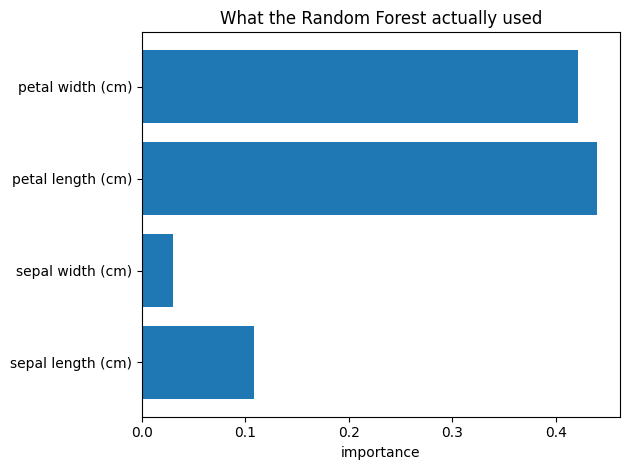

In [6]:
import matplotlib.pyplot as plt

feature_names = load_iris().feature_names
rf = models["RandomForest"]

plt.barh(feature_names, rf.feature_importances_)
plt.xlabel("importance")
plt.title("What the Random Forest actually used")
plt.tight_layout()
plt.show()

---
## Part 4 — The real exercise (60–90 min)

**Do not scroll up.** That's the whole point.

Load a dataset you haven't used and rebuild the entire pipeline from memory:

```python
from sklearn.datasets import load_wine   # or load_breast_cancer
```

Your tasks:
1. Load it, and print the shapes of `X` and `y`.
2. Split it into train and test.
3. Train **two** different models on it.
4. Print accuracy and a confusion matrix for both.
5. Plot the feature importances for the tree-based one.
6. Write one sentence: which model won, and what does the confusion matrix tell you that accuracy doesn't?

You will forget the exact import paths. Good — look them up, that's the skill. Getting stuck and unstuck is the part that sticks.

(178, 13) (178,)
Accuracy of Random Forest Classifier is 1.00
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Accuracy of Decision Tree Classifier is 0.94
[[13  1  0]
 [ 0 14  0]
 [ 1  0  7]]


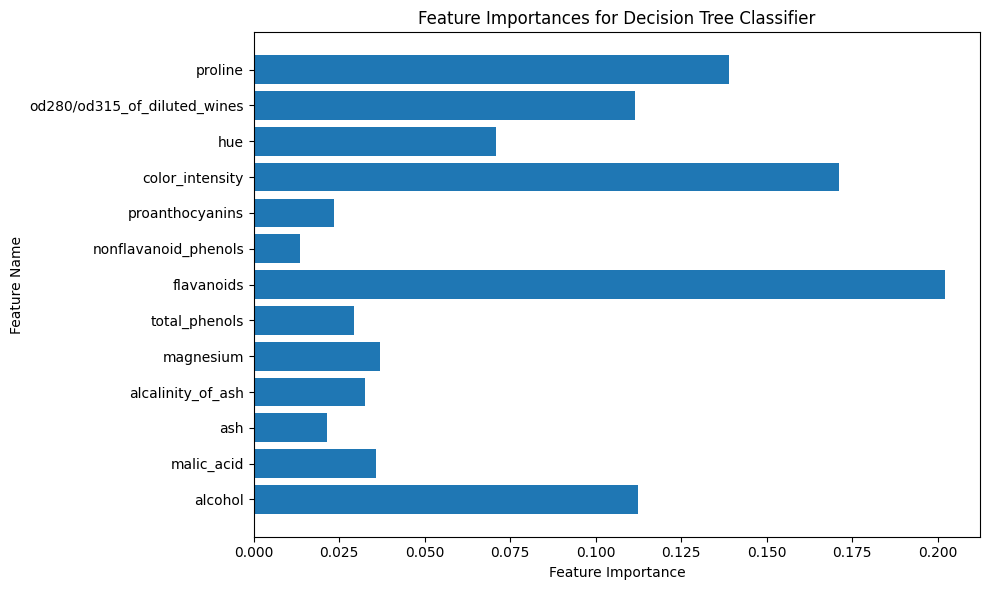

In [15]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier # Corrected import for DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


wine=load_wine()
X,y= wine.data, wine.target
print(X.shape, y.shape)
X_tr, X_te,y_tr,y_te= train_test_split(X, y, test_size=0.2, random_state=42) # Corrected split order
models={
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Decision Tree Classifier" : DecisionTreeClassifier(random_state=42)
}
for name, m in models.items(): # Changed variable name 'm' to 'model_instance' to avoid confusion
  model_instance= m.fit(X_tr,y_tr)
  pred=model_instance.predict(X_te) # Corrected prediction
  acc = accuracy_score(y_te,pred)
  print(f"Accuracy of {name} is {acc:.2f}")
  print(confusion_matrix(y_te, pred)) # Corrected confusion_matrix call

# Plot feature importances for the Random Forest Classifier
# Assuming 'Random Forest Classifier' is tree-based and has feature_importances_
rf_model = models["Random Forest Classifier"]
if hasattr(rf_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    plt.barh(wine.feature_names, rf_model.feature_importances_)
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Feature Importances for {name}")
    plt.tight_layout()
    plt.show()



---
## Part 5 — Close the day (15 min)

1. **File > Save a copy in GitHub**, or download the `.ipynb` and push it to a repo called `ml-20-days`.
2. Add an entry to `notes.md` in that repo:

```markdown
## Day 1 — first sklearn pipeline

**Built:** iris classification with random forest, logistic regression, decision tree.
Rebuilt from scratch on <wine / breast cancer>.

**Learned:**
-
-

**Broke / got stuck on:**
-

**Question I still have:**
-
```

Ten minutes now saves you reconstructing all of this on day 20, when the README has to be written.

---

### If you finished early

Try `sklearn.datasets.load_digits()` — 8x8 images of handwritten numbers, flattened into 64 features. Run the same pipeline on it. A random forest does respectably here, but notice what you had to do: throw away the fact that these are *images* and treat neighbouring pixels as unrelated columns. Holding on to that spatial structure is exactly what a CNN does, and it's why day 11 exists.